<a href="https://colab.research.google.com/github/AnkiPoppel/Cb2330---Project-/blob/main/Different_approach_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [115]:
import numpy as np
import matplotlib.pyplot as plt

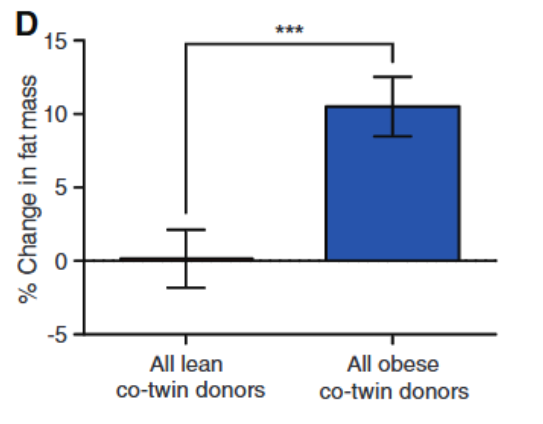

# Forward simulation

Parameters

In [116]:
mice = 1000 #This is the number of mice that we simulate in each group
day = 15 #This is for how long we are running this simulation -> 15 day
v0 = 0.0 #This is our baseline. The report showed that the lean mice on average had a fat mass change of 0% -> therefore it is our starting value
theta = 10/15 #This is the extra daily fat mass gain that the mice get due to the obese microbiota. According to the figure the obese mice gained about 10 percentage points more after 15 days which gives 10/15 per day
sigma = 0.5 #This is added to give some sort of randomness between mice because they don't all react (gain weight equally fast or slow) the same way

Empty lists

In [117]:
lean = [] #Here we create an empty list to which we will append and store the final fat mass changes for the lean mice
obese = [] #Here we create an empty list to which we will append and store the final fat mass changes for the obese mice

In [118]:
for i in range(mice):#We simulate it once for every lean mouse
  fat = 0 #This is our starting fat change according to the figure above
  for j in range(day): #This loop will run as many times as we have days which is 15
    fat = fat + v0 + np.random.normal(0, sigma) #We assume normal distribution. We have assumed that the mean is 0 and the sigma the spread to 0.5 which means that we can generate negative numbers but eh average will be around 0
  lean.append(fat) #We append every final fat change to the lean list -> so every element in the list represents one mouse

for i in range(mice): #We simulate it once for every obese mouse
  fat = 0 #This is our starting fat change according to the figure above
  for j in range(day): #This loop will run as many times as we have days which is 15
    fat = fat + (v0 + theta) + np.random.normal(0, sigma) #We assume normal distribution. We have assumed that the mean is 0 and the sigma the spread to 0.5 which means that we can generate negative numbers but eh average will be around 0. Here we also add the theta term (the extra daily fat mass gain due to the obese microbiota)
  obese.append(fat) #We append every final fat change to the obese list -> so every element in the list represents one mouse


In [119]:
print(f"lean: {lean}") #We print the list which represents the final % fat mass change after 15 days for each and every lean mice
print(f"obese: {obese}") #We print the list which represents the final % fat mass change after 15 days for each and every obese mice

lean: [3.069139186956391, 0.4458479432264604, -1.315008075918314, 2.248286924247648, 1.7856105701377165, 0.805079584603082, -1.5185985368475694, 1.0869595746473866, 1.0101885672597295, 0.8723964446843202, 1.5360879333451005, -0.1952511004273645, 1.0251114365625693, -0.5079652212670592, 1.1065652270087152, 0.9297603349191002, 0.1261054823572597, -2.0484767063674054, -2.553782796602496, 2.0996101954184656, 6.117524669655241, 0.2838839933793212, 1.597304000373919, 0.42549188412995614, -0.48361343767287873, -0.9628323800270054, 0.4630122616981214, 1.3326762994376868, -1.6559844027247395, 1.792241862382157, 0.10689336060003757, 0.5774875631896204, 1.983306105960887, -0.008885798425318253, 0.21511139979313634, -1.7236906273113846, -0.6387567110956623, -0.12788293133999074, 3.232597891952248, -2.4594404527655014, 0.554497577461982, -1.3870421318348443, 2.2962179236235234, 4.627609990220708, -2.52104306570914, 1.002876769896969, -2.173959913258258, 0.9610108115748639, 1.127261674816382, -1.250

In [120]:
mean_lean_mice = np.mean(lean) #Here we calculate the average % fat mass change for the lean mice
mean_obese_mice = np.mean(obese) #Here we calculate the average % fat mass change for the obese mice

print(f"Mean lean: {mean_lean_mice}")
print(f"mean obese: {mean_obese_mice}")

Mean lean: -0.027372171960791378
mean obese: 10.035921968319817


In [121]:
std_lean_mice = np.std(lean) #Here we calculate the standard deviation for the lean mice -> this says how much on average our values differ from the mean
std_obese_mice = np.std(obese) #Here we calculate the standard deviation for the obese mice -> this says how much on average our values differ from the mean

print(f"std lean: {std_lean_mice}")
print(f"std obese: {std_obese_mice}")

std lean: 1.878987847026916
std obese: 1.9377230886070806


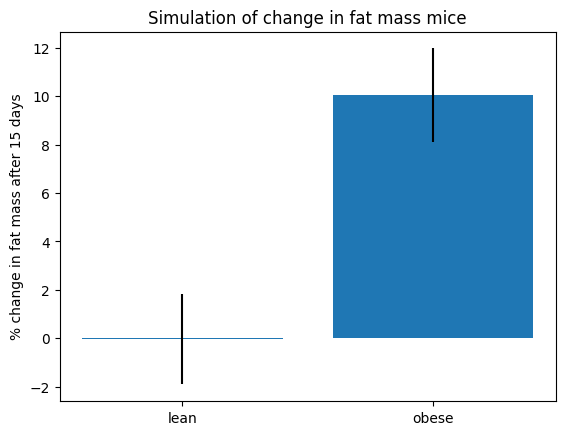

In [122]:
mice_groups = ["lean", "obese"] # we create our two group labels
standard_deviations = [std_lean_mice, std_obese_mice] #Here we take our std, our error bars
mice_means = [mean_lean_mice, mean_obese_mice] #These are the average % fat mass changes
plt.bar(mice_groups, mice_means, yerr=standard_deviations) #Here we plot, where yerr means y-error
plt.ylabel("% change in fat mass after 15 days")
plt.title("Simulation of change in fat mass mice")
plt.show()

# Backward simulation

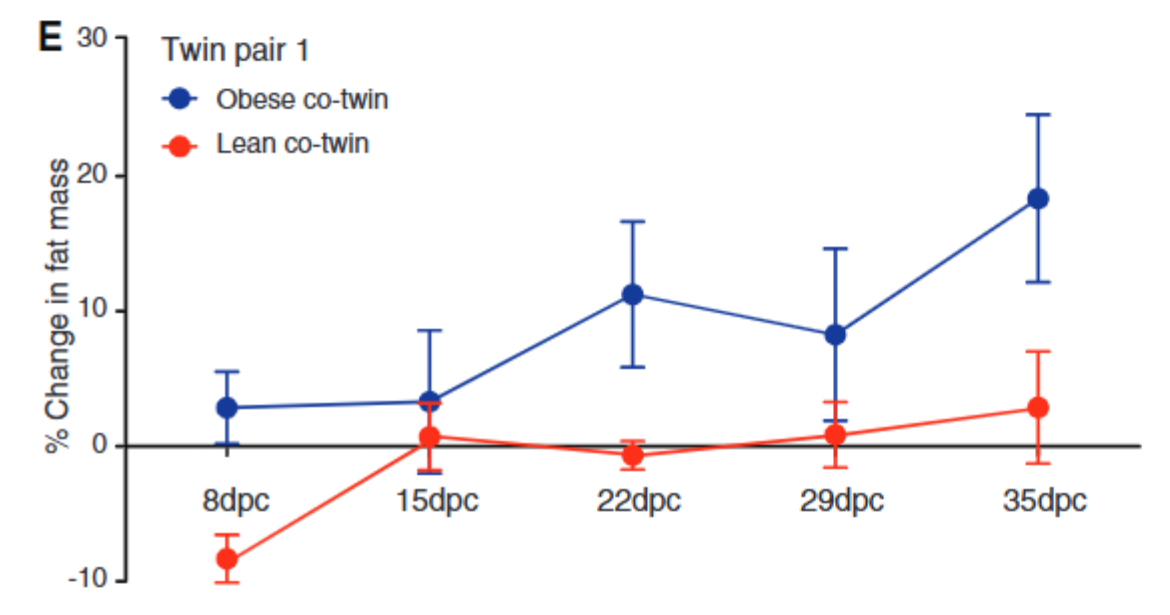

In [123]:
days_report = [8, 15, 22, 29, 35] #The days reported in paper as seen above
lean_report = [-9, 1, -1, 1, 3] #These values were chosen based on the data points for the Lean mice
obese_report = [3, 3, 11, 8, 18] #These values were chosen based on the data points for the Obese mice

In [124]:
best_theta = 0 #Since we dont have a good value for theta yet our best value is simply zero
smallest_error = 10000 #Any error we calculate should be smaller than this very big number -> could choose any number that is big
errors = [] #This is any empty list -> here we append our error values that we get

for theta in np.linspace(0, 1.5, 1000): #Here we test 1000 different theta values between 0 and 1.5
  error = 0 #We start the error at 0
  for i in range(len(days_report)): #Here we go through the time points that they gave in the report
    predicted_value = theta * days_report[i] #Here we calculate the models predicted value for those days
    error = error + (obese_report[i] - predicted_value)**2 #Here we compare the models predicted value with the reports value and we square it to make sure we have no negative errors
    errors.append(error) #Save current error value into errors list
  if error < smallest_error: #If the theta value gives a smaller error than the previous theta values we save it
    smallest_error = error #We save the new smallest value of theta
    best_theta = theta #We save our corresponding theta value

print(best_theta) #The theta that gave the best fit
print(smallest_error) #This is the corresponding error we get, should be as low as possible

0.41291291291291293
42.3474983993002
